In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision.datasets import MNIST
import torchmetrics
from tqdm import tqdm
import torchhd
from torchhd.models import Centroid
from torchhd import embeddings

# Use the GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using {} device".format(device))

DIMENSIONS = 10000
IMG_SIZE = 28
NUM_LEVELS = 1000
BATCH_SIZE = 1 

transform = torchvision.transforms.ToTensor()

train_ds = MNIST("../data", train=True, transform=transform, download=True)
train_ld = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

test_ds = MNIST("../data", train=False, transform=transform, download=True)
test_ld = torch.utils.data.DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

class Encoder(nn.Module):
    def __init__(self, out_features, size, levels):
        super(Encoder, self).__init__()
        self.flatten = torch.nn.Flatten()
        self.position = embeddings.Random(size * size, out_features)
        self.value = embeddings.Level(levels, out_features)

    def forward(self, x):
        x = self.flatten(x)
        sample_hv = torchhd.bind(self.position.weight, self.value(x))
        sample_hv = torchhd.multiset(sample_hv)
        return torchhd.hard_quantize(sample_hv)

encode = Encoder(DIMENSIONS, IMG_SIZE, NUM_LEVELS)
encode = encode.to(device)

num_classes = len(train_ds.classes)
model = Centroid(DIMENSIONS, num_classes)
model = model.to(device)


with torch.no_grad():
    for samples, labels in tqdm(train_ld, desc="Training"):
        samples = samples.to(device)
        labels = labels.to(device)
        samples_hv = encode(samples)
        model.add(samples_hv, labels)

accuracy = torchmetrics.Accuracy("multiclass", num_classes=num_classes)

with torch.no_grad():
    model.normalize()

    for samples, labels in tqdm(test_ld, desc="Testing"):
        samples = samples.to(device)

        samples_hv = encode(samples)
        outputs = model(samples_hv, dot=False)
        accuracy.update(outputs.cpu(), labels)

print(f"Testing accuracy of {(accuracy.compute().item() * 100):.3f}%")

Using cpu device


In [120]:
transform = torchvision.transforms.ToTensor()

train_ds = MNIST("../data", train=True, transform=transform, download=True)
train_ld = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

test_ds = MNIST("../data", train=False, transform=transform, download=True)
test_ld = torch.utils.data.DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

In [122]:
train_ld

In [3]:
transform

ToTensor()

In [4]:
class Encoder(nn.Module):
    def __init__(self, out_features, size, levels):
        super(Encoder, self).__init__()
        self.flatten = torch.nn.Flatten()
        self.position = embeddings.Random(size * size, out_features)
        self.value = embeddings.Level(levels, out_features)

    def forward(self, x):
        x = self.flatten(x)
        sample_hv = torchhd.bind(self.position.weight, self.value(x))
        sample_hv = torchhd.multiset(sample_hv)
        return torchhd.hard_quantize(sample_hv)

encode = Encoder(DIMENSIONS, IMG_SIZE, NUM_LEVELS)
encode = encode.to(device)

num_classes = len(train_ds.classes)
model = Centroid(DIMENSIONS, num_classes)
model = model.to(device)

In [5]:
encode

Encoder(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (position): Random(784, 10000)
  (value): Level(1000, 10000)
)

In [6]:
print(encode.flatten)

Flatten(start_dim=1, end_dim=-1)


In [7]:
encode.position.weight

Parameter(MAPTensor([[-1., -1.,  1.,  ..., -1., -1.,  1.],
           [ 1., -1.,  1.,  ...,  1.,  1.,  1.],
           [-1.,  1.,  1.,  ..., -1.,  1.,  1.],
           ...,
           [ 1., -1.,  1.,  ...,  1., -1., -1.],
           [ 1., -1., -1.,  ..., -1., -1.,  1.],
           [-1.,  1.,  1.,  ...,  1., -1.,  1.]]))

In [8]:
encode.position.weight.shape

torch.Size([784, 10000])

In [9]:
num_classes

10

In [10]:
model

Centroid(in_features=10000, out_features=10)

In [11]:
from tqdm import tqdm
with torch.no_grad():
    for samples, labels in tqdm(train_ld, desc="Training"):
        samples = samples.to(device)
        labels = labels.to(device)
        samples_hv = encode(samples)
        model.add(samples_hv, labels)

Training: 100%|██████████████████████████████████████████████████████████████████| 60000/60000 [26:35<00:00, 37.61it/s]


In [12]:
accuracy = torchmetrics.Accuracy("multiclass", num_classes=num_classes)

with torch.no_grad():
    model.normalize()

    for samples, labels in tqdm(test_ld, desc="Testing"):
        samples = samples.to(device)

        samples_hv = encode(samples)
        outputs = model(samples_hv, dot=False)
        accuracy.update(outputs.cpu(), labels)

print(f"Testing accuracy of {(accuracy.compute().item() * 100):.3f}%")

Testing: 100%|███████████████████████████████████████████████████████████████████| 10000/10000 [03:22<00:00, 49.29it/s]

Testing accuracy of 82.840%


In [129]:
import numpy as np
import torch
from transformers import BertTokenizer, BertModel
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import time
import psutil
import os
from transformers.file_utils import ModelOutput
# Prepare the data
dataset = pd.read_csv('spamdata.csv')
dataset = dataset[:501]

texts = dataset.text.tolist()
labels = dataset.label.tolist()

def get_model_size(model):
    param_size = 0
    param_sum = 0
    for param in model.parameters():
        param_size += param.nelement() * param.element_size()
        param_sum += param.nelement()
    buffer_size = 0
    buffer_sum = 0
    for buffer in model.buffers():
        buffer_size += buffer.nelement() * buffer.element_size()
        buffer_sum += buffer.nelement()
    all_size = (param_size + buffer_size) / 1024 / 1024
    return all_size

model_name = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertModel.from_pretrained(model_name)

# Tokenize texts and get BERT embeddings
def get_bert_embeddings(texts):
    inputs = tokenizer(texts, return_tensors='pt', padding=True, truncation=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    # Use the [CLS] token embedding
    embeddings = outputs.last_hidden_state[:, 0, :].numpy()
    return embeddings

# Split the data
X_train_texts, X_test_texts, y_train, y_test = train_test_split(texts, labels, test_size=0.2, random_state=42)

# Measure the training time for getting embeddings
start_time = time.time()
X_train = get_bert_embeddings(X_train_texts)
X_test = get_bert_embeddings(X_test_texts)
end_time = time.time()
embedding_time = end_time - start_time

# Ensure embeddings are computed correctly
print("Training embeddings shape:", X_train.shape)
print("Test embeddings shape:", X_test.shape)
print(f"Time to get BERT embeddings: {embedding_time:.2f} seconds")

# Step 5: Train the SVM classifier
# Create an SVM pipeline with standard scaling
svm_classifier = make_pipeline(StandardScaler(), SVC(kernel='linear', C=1.0))

# Measure training time
start_time = time.time()
svm_classifier.fit(X_train, y_train)
end_time = time.time()
training_time = end_time - start_time

# Step 6: Evaluate the model
start_time = time.time()
y_pred = svm_classifier.predict(X_test)
end_time = time.time()
inference_time = end_time - start_time

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Training time: {training_time:.2f} seconds")
print(f"Inference time: {inference_time:.4f} seconds")
print("Classification Report:\n", classification_report(y_test, y_pred))

# Memory usage
process = psutil.Process(os.getpid())
memory_info = process.memory_info()
memory_usage = memory_info.rss / 1024 / 1024  # in MB

# Model size
model_size = get_model_size(model)

print(f"Memory usage: {memory_usage:.2f} MB")
print(f"Model size: {model_size:.2f} MB")

Training embeddings shape: (400, 768)
Test embeddings shape: (101, 768)
Time to get BERT embeddings: 86.02 seconds
Accuracy: 98.02%
Training time: 0.07 seconds
Inference time: 0.0057 seconds
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99        86
           1       0.93      0.93      0.93        15

    accuracy                           0.98       101
   macro avg       0.96      0.96      0.96       101
weighted avg       0.98      0.98      0.98       101

Memory usage: 1587.07 MB
Model size: 417.65 MB


In [15]:
import torch
import torch.nn as nn
from transformers import BertTokenizer, BertModel
from tqdm import tqdm
import torchhd
from torchhd.models import Centroid
from torchhd import embeddings
from sklearn.model_selection import train_test_split
import pandas as pd

# Load pre-trained BERT model and tokenizer
model_name = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(model_name)
bert_model = BertModel.from_pretrained(model_name)

# Prepare the data
dataset = pd.read_csv('spamdata.csv')
dataset = dataset[:100]  # Only use the first 100 samples for simplicity

texts = dataset.text.tolist()
labels = dataset.label.tolist()

# Tokenize texts and get BERT embeddings
def get_bert_embeddings(texts):
    inputs = tokenizer(texts, return_tensors='pt', padding=True, truncation=True, max_length=512)
    with torch.no_grad():
        outputs = bert_model(**inputs)
    # Use the [CLS] token embedding
    embeddings = outputs.last_hidden_state[:, 0, :]
    return embeddings

# Split the data
X_train_texts, X_test_texts, y_train, y_test = train_test_split(texts, labels, test_size=0.2, random_state=42)

# Get BERT embeddings for training and testing data
X_train = get_bert_embeddings(X_train_texts)
X_test = get_bert_embeddings(X_test_texts)

# Hyperdimensional Computing Encoder
class Encoder(nn.Module):
    def __init__(self, out_features, levels):
        super(Encoder, self).__init__()
        self.position = embeddings.Random(out_features, out_features)  # Adjust dimensions if needed
        self.value = embeddings.Level(levels, out_features)

    def forward(self, x):
        sample_hv = torchhd.bind(self.position.weight, x)
        sample_hv = torchhd.multiset(sample_hv)
        return torchhd.hard_quantize(sample_hv)

# Define dimensions and other parameters
DIMENSIONS = 768  # Adjust as needed
NUM_CLASSES = 2  # Assuming binary classification
encoder = Encoder(DIMENSIONS, NUM_CLASSES)

# Move encoder to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
encoder = encoder.to(device)

# Convert training data to device
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = torch.tensor(y_train).to(device)
y_test = torch.tensor(y_test).to(device)

# Hyperdimensional Computing Centroid Model
model = Centroid(DIMENSIONS, NUM_CLASSES).to(device)

# Training loop
with torch.no_grad():
    for sample, label in tqdm(zip(X_train, y_train), desc="Training"):
        sample = sample.unsqueeze(0).to(device)  # Add batch dimension
        label = torch.tensor([label]).to(device)  # Ensure label is a tensor
        sample_hv = encoder(sample)
        sample_hv = sample_hv.squeeze(0)  # Remove batch dimension for single sample processing

        # Ensure sample_hv has the correct dimension
        assert sample_hv.shape == (DIMENSIONS,), f"Unexpected shape: {sample_hv.shape}"

        # Ensure label is a tensor with the correct shape
        label_tensor = torch.tensor([label.item()]).to(device)

        # Add the sample_hv to the model with the corresponding label
        model.add(sample_hv, label_tensor)

Training: 0it [00:00, ?it/s]


RuntimeError: index_add_(): Number of indices (1) should be equal to source.size(dim): (768), for dim: 0

In [13]:
sample_hv.shape

torch.Size([768])

In [11]:
encoder 

Encoder(
  (position): Random(768, 768)
  (value): Level(2, 768)
)

In [4]:
encoder

Encoder(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (position): Random(900, 768)
  (value): Level(2, 768)
)

In [6]:
with torch.no_grad():
    for samples, labels in tqdm(zip(X_train,y_train), desc="Training"):
        samples = samples.to(device)
        labels = labels.to(device)
        samples_hv = encoder(samples)
        model.add(samples_hv, labels)

Training: 0it [00:00, ?it/s]


IndexError: Dimension out of range (expected to be in range of [-1, 0], but got 1)

In [39]:
import numpy as np
from sklearn import datasets
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from scipy.stats.qmc import Sobol

# Load Iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Normalize the dataset
def normalize_data(encoded_data):
    return encoded_data / np.linalg.norm(encoded_data, axis=1)[:, np.newaxis]
X_scaled = normalize_data(X)

def generate_sobol_sequence(size, dimension):
    """
    Generates a Sobol sequence.
    
    Parameters:
    - size: Number of samples in the sequence
    - dimension: Dimensionality of the sequence
    
    Returns:
    - Sobol sequence
    """
    sobol_engine = Sobol(dimension)
    return sobol_engine.random(n=size)

def encode_uHD(data, vector_size=4):
    """
    Encodes the input data into hypervectors using Sobol sequences.
    
    Parameters:
    - data: Normalized data to encode
    - vector_size: Size of the hypervector
    
    Returns:
    - Encoded hypervectors
    """
    num_samples, num_features = data.shape
    encoded_data = np.zeros((num_samples, vector_size), dtype=int)
    sobol_seq = generate_sobol_sequence(vector_size, num_features)
    
    for i in range(num_samples):
        for j in range(num_features):
            threshold = data[i, j]
            for k in range(vector_size):
                encoded_data[i, k] += 1 if sobol_seq[k, j] >= threshold else -1
    
    return encoded_data

# Encode the dataset
encoded_X = encode_uHD(X_scaled, vector_size=4)
encoded_X

array([[ 0,  0,  4,  0],
       [ 0,  0,  4,  0],
       [ 0,  0,  4,  0],
       [ 0,  0,  4,  0],
       [ 0,  0,  4,  0],
       [ 0,  0,  4,  0],
       [ 0,  0,  4,  0],
       [ 0,  0,  4,  0],
       [ 0,  0,  4,  0],
       [ 0,  0,  4,  0],
       [ 0,  0,  4,  0],
       [ 0,  0,  4,  0],
       [ 0,  0,  4,  0],
       [ 0,  0,  4,  0],
       [ 0,  0,  4,  0],
       [ 0,  0,  4,  0],
       [ 0,  0,  4,  0],
       [ 0,  0,  4,  0],
       [ 0,  0,  4,  0],
       [ 0,  0,  4,  0],
       [ 0,  0,  4,  0],
       [ 0,  0,  4,  0],
       [ 0,  0,  2,  0],
       [ 0,  0,  4,  0],
       [ 0,  0,  4,  0],
       [ 0,  0,  4,  0],
       [ 0,  0,  4,  0],
       [ 0,  0,  4,  0],
       [ 0,  0,  4,  0],
       [ 0,  0,  4,  0],
       [ 0,  0,  4,  0],
       [ 0,  0,  4,  0],
       [ 0,  0,  4,  0],
       [ 0,  0,  4,  0],
       [ 0,  0,  4,  0],
       [ 0,  0,  4,  0],
       [ 0,  0,  4,  0],
       [ 0,  0,  4,  0],
       [ 0,  0,  4,  0],
       [ 0,  0,  4,  0],


In [40]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(encoded_X, y, test_size=0.3, random_state=42)

# Train an SVM model
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = svm_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print('Classification Report:')
print(report)

Accuracy: 0.9111111111111111
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        19
           1       0.91      0.77      0.83        13
           2       0.81      1.00      0.90        13

    accuracy                           0.91        45
   macro avg       0.91      0.91      0.90        45
weighted avg       0.92      0.91      0.91        45



In [4]:
from qiskit.circuit.library import ZZFeatureMap
from qiskit.primitives import Sampler
from qiskit_algorithms.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from sklearn.metrics import accuracy_score
from qiskit_machine_learning.algorithms import QSVC

C:\Users\abuka\AppData\Roaming\Python\Python311\site-packages\qiskit\visualization\circuit\matplotlib.py:266: FutureWarning: The default matplotlib drawer scheme will be changed to "iqp" in a following release. To silence this warning, specify the current default explicitly as style="clifford", or the new default as style="iqp".
  self._style, def_font_ratio = load_style(self._style)


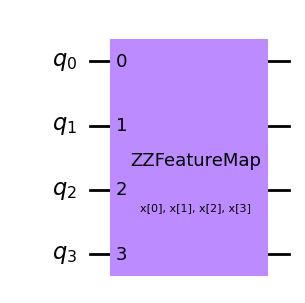

In [43]:
feature_map = ZZFeatureMap(feature_dimension=encoded_X.shape[1], reps=2, entanglement='full')
feature_map.draw("mpl")

In [44]:
sampler = Sampler()
fidelity = ComputeUncompute(sampler=sampler)
quantum_kernel = FidelityQuantumKernel(fidelity=fidelity, feature_map=feature_map)

In [45]:
%%time
qsvc = QSVC(quantum_kernel=quantum_kernel)
qsvc.fit(X_train, y_train)
y_pred = qsvc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 91.11%
CPU times: total: 2min 16s
Wall time: 4min 28s


In [46]:
y_pred = qsvc.predict(X_test)
y_pred

array([1, 0, 2, 2, 1, 0, 1, 2, 2, 1, 2, 0, 0, 0, 0, 1, 2, 1, 2, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0, 1, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2, 1, 1, 0,
       0])

In [47]:
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print('Classification Report:')
print(report)

Accuracy: 0.9111111111111111
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        19
           1       0.91      0.77      0.83        13
           2       0.81      1.00      0.90        13

    accuracy                           0.91        45
   macro avg       0.91      0.91      0.90        45
weighted avg       0.92      0.91      0.91        45



In [11]:
import numpy as np
from sklearn import datasets
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from scipy.stats.qmc import Sobol

# Load the breast cancer dataset
cancer = datasets.load_breast_cancer()

X = cancer.data[:100]
y = cancer.target[:100]

# Normalize the dataset
def normalize_data(encoded_data):
    return encoded_data / np.linalg.norm(encoded_data, axis=1)[:, np.newaxis]
X_scaled = normalize_data(X)

def generate_sobol_sequence(size, dimension):
    """
    Generates a Sobol sequence.
    
    Parameters:
    - size: Number of samples in the sequence
    - dimension: Dimensionality of the sequence
    
    Returns:
    - Sobol sequence
    """
    sobol_engine = Sobol(dimension, scramble=True)
    return sobol_engine.random(n=size)

def encode_uHD(data, vector_size=10):
    """
    Encodes the input data into hypervectors using Sobol sequences.
    
    Parameters:
    - data: Normalized data to encode
    - vector_size: Size of the hypervector
    
    Returns:
    - Encoded hypervectors
    """
    num_samples, num_features = data.shape
    encoded_data = np.zeros((num_samples, vector_size), dtype=int)
    sobol_seq = generate_sobol_sequence(vector_size, num_features)
    
    for i in range(num_samples):
        for j in range(num_features):
            threshold = data[i, j]
            for k in range(vector_size):
                encoded_data[i, k] += 1 if sobol_seq[k, j] >= threshold else -1
    
    return encoded_data

# Encode the dataset
encoded_X = encode_uHD(X_scaled, vector_size=10)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(encoded_X, y, test_size=0.3, random_state=42)

# Train an SVM model
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = svm_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print('Classification Report:')
print(report)

Accuracy: 0.9333333333333333
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        23
           1       0.86      0.86      0.86         7

    accuracy                           0.93        30
   macro avg       0.91      0.91      0.91        30
weighted avg       0.93      0.93      0.93        30



C:\Users\abuka\anaconda3\Lib\site-packages\scipy\stats\_qmc.py:763: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)


C:\Users\abuka\AppData\Roaming\Python\Python311\site-packages\qiskit\visualization\circuit\matplotlib.py:266: FutureWarning: The default matplotlib drawer scheme will be changed to "iqp" in a following release. To silence this warning, specify the current default explicitly as style="clifford", or the new default as style="iqp".
  self._style, def_font_ratio = load_style(self._style)


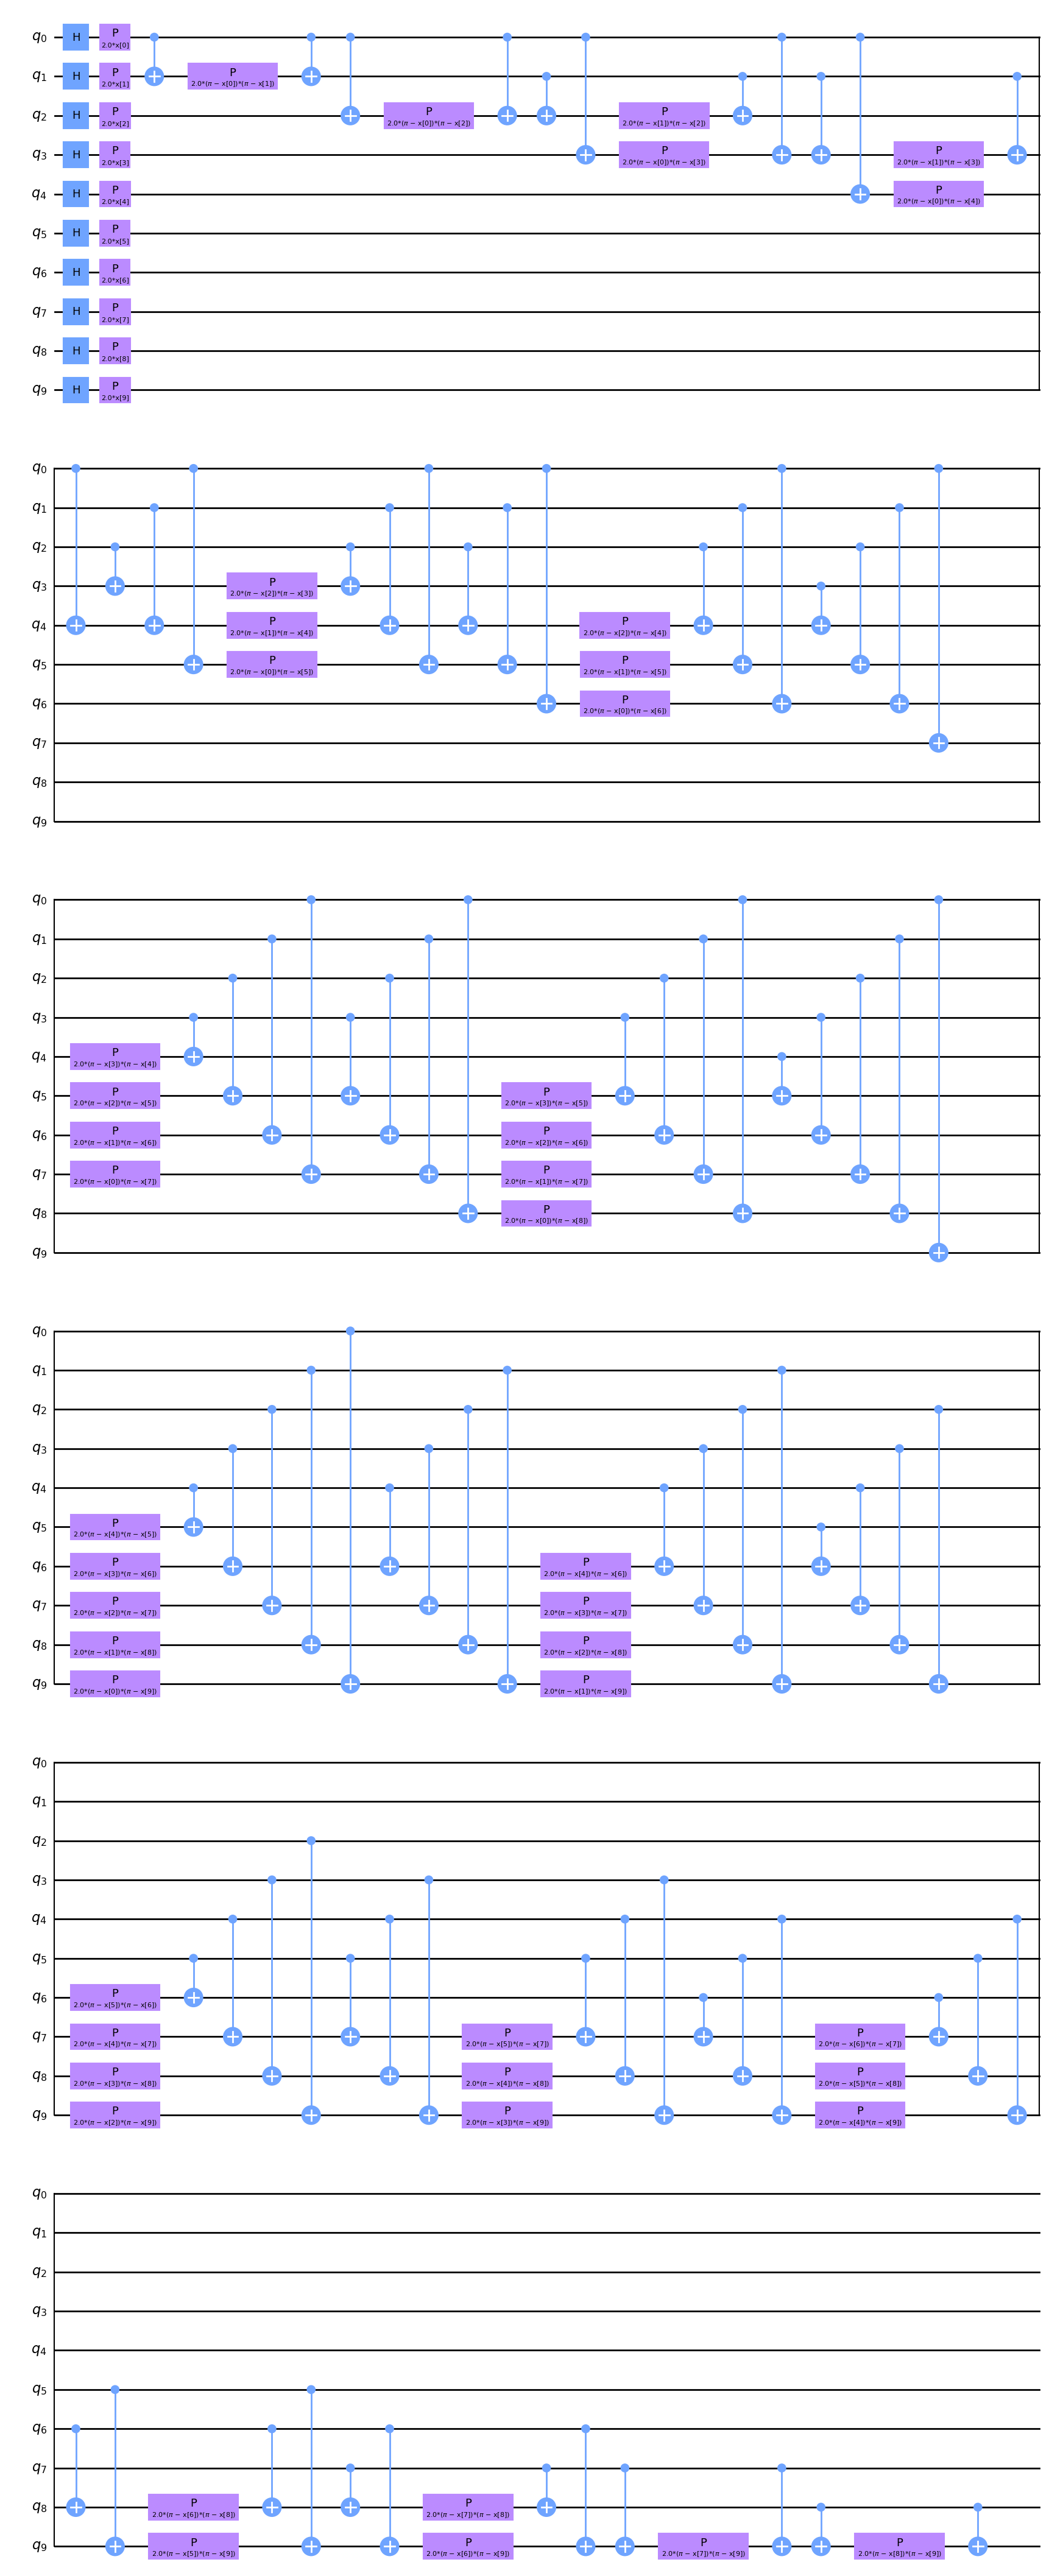

In [12]:
feature_map = ZZFeatureMap(feature_dimension=encoded_X.shape[1], reps=1, entanglement='full')
feature_map.decompose().draw("mpl")

In [13]:
sampler = Sampler()
fidelity = ComputeUncompute(sampler=sampler)
quantum_kernel = FidelityQuantumKernel(fidelity=fidelity, feature_map=feature_map)

In [14]:
%%time
qsvc = QSVC(quantum_kernel=quantum_kernel)
qsvc.fit(X_train, y_train)
y_pred = qsvc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 93.33%
CPU times: total: 4min 57s
Wall time: 9min 45s


In [15]:
from qiskit_machine_learning.algorithms.classifiers import VQC
from qiskit.algorithms.optimizers import ISRES, ADAM, COBYLA

In [16]:
from qiskit.circuit.library import RealAmplitudes
ansatz = RealAmplitudes(num_qubits=encoded_X.shape[1], reps=1)
optimizer = ADAM(maxiter=100)

In [17]:
%%time
vqc = VQC(
    sampler=sampler,
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=optimizer,
)
vqc.fit(X_train,y_train)

CPU times: total: 2h 21min 19s
Wall time: 3h 19min 8s
